In [ ]:
import pickle
import os
import matplotlib.pyplot as plt



file_path = os.path.join(
    ".",
    "RWalks_trade_off_result_all.pkl"
)

with open(file_path, "rb") as f:
    trade_off = pickle.load(f)



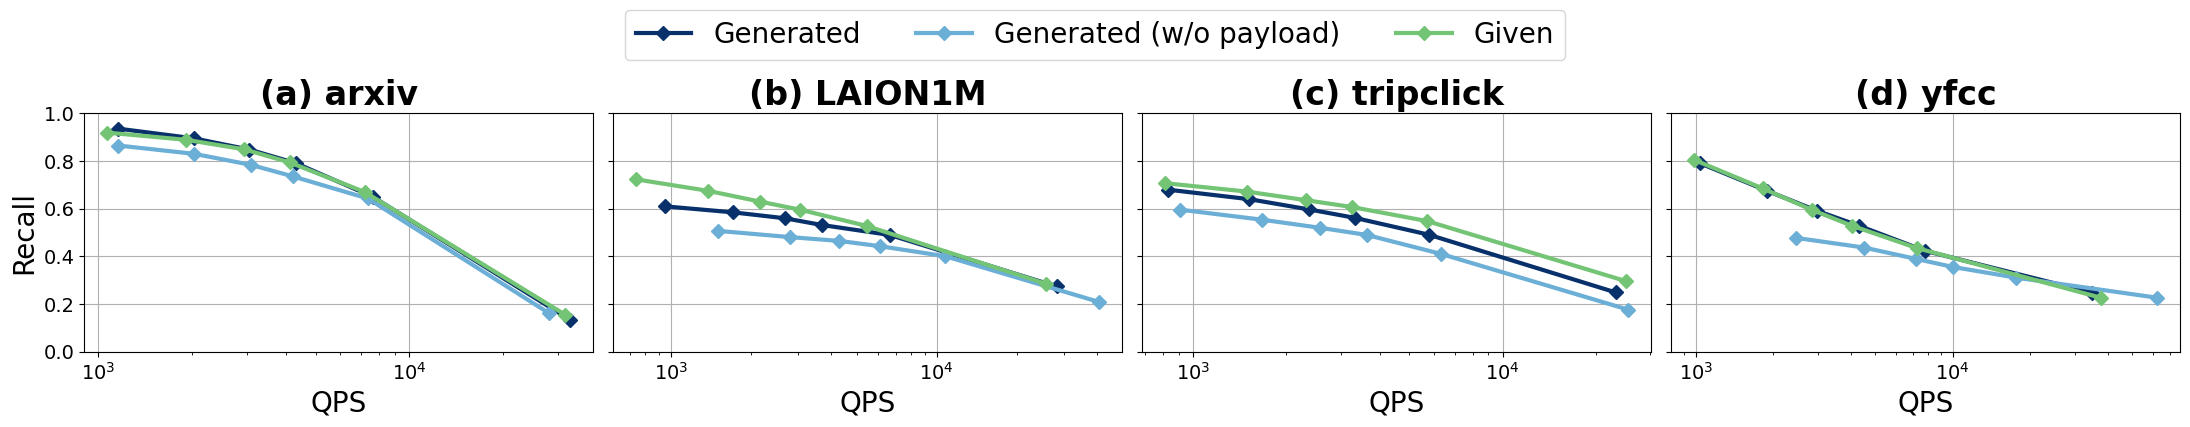

In [53]:
import matplotlib.pyplot as plt

# =================================================
# Fontsize 옵션 (여기만 만지면 전체 조절됨)
# =================================================
FS_TITLE   = 18   # 전체 figure title
FS_SUBTITLE = 24  # subplot title
FS_LABEL   = 20   # axis label
FS_TICK    = 14   # tick label
FS_LEGEND  = 20   # legend text

# =================================================
# subplot 대상 dataset
# =================================================
datasets = ["arxiv", "LAION1M", "tripclick", "yfcc"]
dataset_names = ["(a) arxiv", "(b) LAION1M", "(c) tripclick", "(d) yfcc"]
# =================================================
# 색상 매핑
# =================================================
COLOR_MAP = {
    "generated": "#08306B",
    "generated_wo_payload": "#6BAED6",
    "given": "#74C476",
}

LABEL_MAP = {
    "generated": "Generated",
    "generated_wo_payload": "Generated (w/o payload)",
    "given": "Given",
}

# =================================================
# Figure
# =================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

# =================================================
# 각 dataset별 subplot
# =================================================
for ax, dataset, dataset_name in zip(axes[:4], datasets, dataset_names):

    for dataset_key, stats_dict in trade_off.items():
        if not dataset_key.startswith(dataset):
            continue

        K_ns = sorted(stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        if dataset_key.endswith("_generated_wo_payload"):
            style = "generated_wo_payload"
        elif dataset_key.endswith("_generated"):
            style = "generated"
        else:
            style = "given"

        ax.plot(
            qps_values,
            recall_values,
            marker="D",
            markersize=7,
            linewidth=3.0,
            color=COLOR_MAP[style],
            label=LABEL_MAP[style],
        )

    ax.set_title(dataset_name, fontsize=FS_SUBTITLE, fontweight="bold")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True)

    ax.set_xlabel("QPS", fontsize=FS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_TICK)

# =================================================
# 공통 Y label
# =================================================
axes[0].set_ylabel("Recall", fontsize=FS_LABEL)

# =================================================
# 상단 Legend (1 row)
# =================================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=True,
    bbox_to_anchor=(0.5, 1.09),
)


# =================================================
# Layout
# =================================================
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


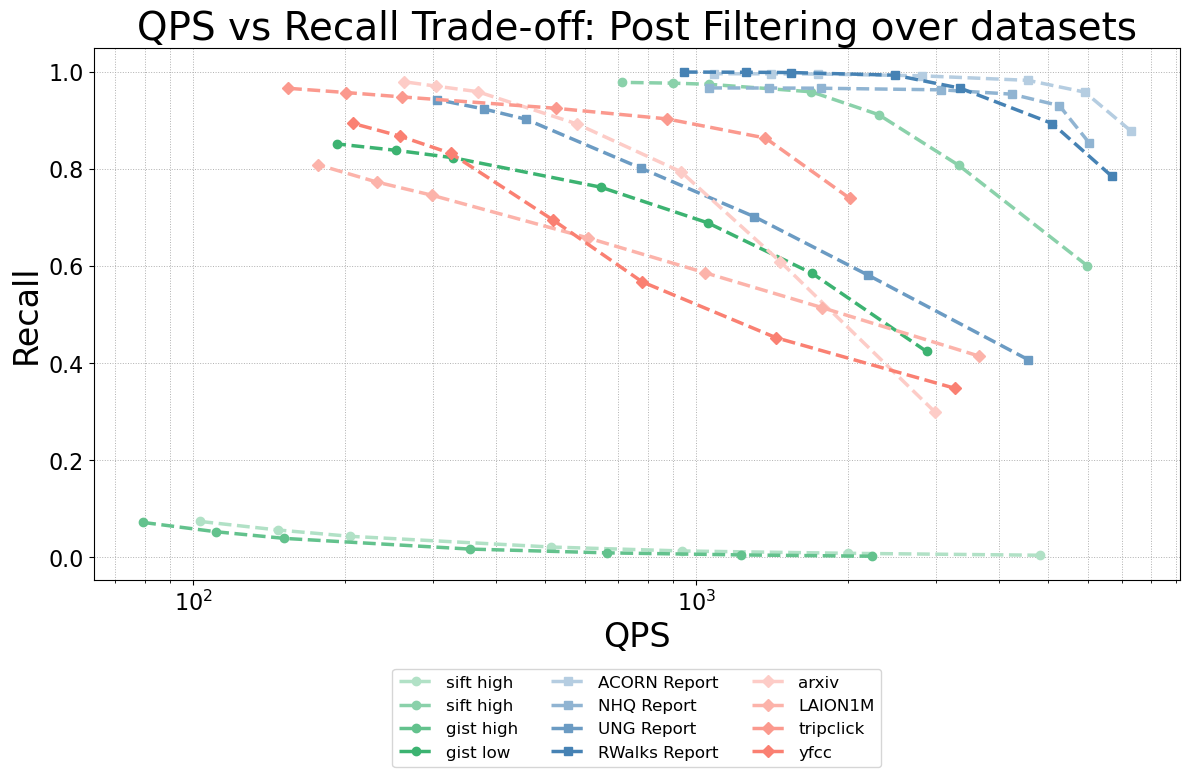

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# -----------------------------
# 1) 데이터셋 클래스 정의
# -----------------------------
GENERATOR_KEYS = {"sift_high", "sift_low", "gist_high", "gist_low"}
SYNTH_KEYS     = {"sift1m_ACORN", "sift1m_UNG", "sift1m_NHQ", "sift1m_RWalks"}
# 나머지는 모두 semi-real

# -----------------------------
# 2) 클래스별 스타일 (선/마커 통일)
# -----------------------------
STYLE_BY_CLASS = {
    "generator": {"linestyle": "--",  "marker": "o", "linewidth": 2.5, "markersize": 6},  # 초록계열 (나중에 색만 바뀜)
    "synthetic": {"linestyle": "--", "marker": "s", "linewidth": 2.5, "markersize": 6},  # 파랑계열
    "semi":      {"linestyle": "--", "marker": "D", "linewidth": 2.5, "markersize": 6},  # 붉은계열
}

# -----------------------------
# 3) dataset_key → label 매핑 (건드리지 말라고 한 부분)
# -----------------------------
LABEL_MAP = {
    "sift_high":   "sift high",
    "sift_low":    "sift high",
    "gist_low":    "gist low",
    "gist_high":   "gist high",
    "sift1m_UNG":  "UNG Report",
    "sift1m_RWalks": "RWalks Report",
    "sift1m_NHQ":  "NHQ Report",
    "sift1m_ACORN": "ACORN Report",
    # 나머지는 key 그대로 label 사용
}

# -----------------------------
# 4) 베이스 컬러 & 그라데이션 생성 함수
# -----------------------------
BASE_COLOR_BY_CLASS = {
    "synthetic":     "steelblue",      # 0~3
    "semi":          "salmon",         # 4~7
    "generator":     "mediumseagreen", # 8~11
}

# def make_grad_colors(base_color, n):
#     """
#     base_color RGB는 유지하고, alpha 값만 0.4~1.0 범위로 변화시키는 RGBA 리스트 반환.
#     """
#     base_rgb = mcolors.to_rgb(base_color)

#     # 0.4 ~ 1.0 사이에서 alpha 변화
#     alphas = np.linspace(0.4, 1.0, max(1, n))

#     colors = []
#     for a in alphas:
#         colors.append((*base_rgb, a))  # (r, g, b, alpha)
#     return colors
def make_grad_colors(base_color, n): 
    """ 
    base_color를 기준으로 n개의 밝기 다른 색을 만든다. 흰색과 섞어서 점점 밝아지는 톤의 리스트를 반환. 
    """ 
    base_rgb = np.array(mcolors.to_rgb(base_color)) 
    white = np.ones(3) # 0.4 ~ 1.0 사이에서 섞기 (0.4: 많이 하양, 1.0: 원색에 가까움) 
    alphas = np.linspace(0.4, 1.0, max(1, n)) 
    colors = [] 
    for a in alphas: 
        rgb = a * base_rgb + (1 - a) * white 
        colors.append(tuple(rgb)) 
    return colors
# -----------------------------
# 5) trade_off를 클래스별로 그룹핑
# -----------------------------
generator_keys = [k for k in trade_off.keys() if k in GENERATOR_KEYS]
synthetic_keys = [k for k in trade_off.keys() if k in SYNTH_KEYS]
semi_keys      = [k for k in trade_off.keys() if k not in GENERATOR_KEYS | SYNTH_KEYS]

GROUPS = {
    "generator": generator_keys,
    "synthetic": synthetic_keys,
    "semi":      semi_keys,
}

# 클래스별 색 리스트 미리 생성
CLASS_COLORS = {}
for cls, keys in GROUPS.items():
    base = BASE_COLOR_BY_CLASS[cls]
    CLASS_COLORS[cls] = make_grad_colors(base, len(keys))


# -----------------------------
# 6) 플롯
# -----------------------------
plt.figure(figsize=(12, 8))

for cls, keys in GROUPS.items():
    style = STYLE_BY_CLASS[cls]
    colors = CLASS_COLORS[cls]

    for local_idx, dataset_key in enumerate(keys):
        stats_dict = trade_off[dataset_key]
        label = LABEL_MAP.get(dataset_key, dataset_key)
        color = colors[local_idx]
        # if label == "UNG Report":
        #     # color = "Blue"
        #     style["linewidth"] = 4
        #     style["markersize"] = 9

        # K_ns 정렬 (키가 "10", "20" 같은 문자열 숫자라고 가정)
        K_ns = sorted(stats_dict.keys(), key=lambda x: int(x))

        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker=style["marker"],
            markersize=style["markersize"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            color=color,
            label=label,
        )

plt.xscale("log")
plt.xlabel("QPS", fontsize=24)
plt.ylabel("Recall", fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("QPS vs Recall Trade-off: Post Filtering over datasets", fontsize=28)
plt.legend(
    fontsize=12,
    ncol=3,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
)
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()
